# University Physics with Modern Physics

<img src="..//pics/cover.png" width=400> 



In [1]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1


<IPython.core.display.Javascript object>

All imports succeeded!


In [2]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec


In [3]:
!python --version

Python 3.12.10


In [4]:
pwd


'c:\\Users\\crodr\\BK_tech\\Physics\\BK_University_Physics_Young_15\\ch02'

# 2 Motion Along a Stright Line
## EXERCISES
### Section 2.3 Average and Instantaneous Acceleration

page 88

#### 2.13 

• CALC A turtle crawls along a straight line, which we’ll
call the x-axis with the positive direction to the right. The equation
for the turtle’s position as a function of time is $x(t)= 50.0 cm + (2.00 cm/s)t -(0.0625 cm/s^2)t^2$. 

**(a)** Find the turtle’s initial velocity,
initial position, and initial acceleration. 

In [8]:
# Define the symbolic time variable and constants
a, b, c, d, t, x = sp.symbols("a, b, c, d, t, x")

# Define position function x(t)
x = b + c * t - d * t**2

# Display the resulting expression
display(Math(rf"x(t) = {sp.latex(x)}"))

# Compute velocity v(t) as the derivative of x(t) with respect to t
v = sp.diff(x, t)

# Display the resulting expression
display(Math(rf"v(t) = {sp.latex(v)}"))

# Compute acceleration a(t) as the second derivative of x(t) with respect to t
a = sp.diff(x, t, 2)

# Display the resulting expression
display(Math(rf"a(t) = {sp.latex(a)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# defines constants
b = 50.0 * u.cm
c = 2.00 * (u.cm / u.s)
d = 0.0625 * (u.cm / u.s**2)


# define position function
def x(t):
    return b + c * t - d * t**2


# define velocity function
def v(t):
    return c - 2 * d * t


# define acceleration function
def a(t):
    return -2 * d


# Find initial values
t0 = 0 * u.s

x0 = x(t0)
print(f"At t = {t0} position x0 = {x0}")

v0 = v(t0)
print(f"At t = {t0} velocity v0 = {v0}")

a0 = a(t0)
print(f"At t = {t0} acceleration a0 = {a0}")


At t = 0.0 s position x0 = 50.0 cm
At t = 0.0 s velocity v0 = 2.0 cm / s
At t = 0.0 s acceleration a0 = -0.125 cm / s2


**(b)** At what time t is the velocity
of the turtle zero? 

In [ ]:
# v(t) = c -2dt = 0 ==> t = c / (2d)
t = c / (2 * d)
print(f"Velocity is zero at t= {t}")

# check result
print(f"Velocity at {t}: {v(t)}")


Velocity is zero at t= 16.0 s
Velocity at 16.0 s: 0.0 cm / s


(c) How long after starting does it take the turtle to
return to its starting point?

In [58]:
import sympy as sp

# 1. Define symbolic variables
a, b, c, d, t, o = sp.symbols("a b c d t o", real=True)

# 2. Define equation and solve symbolically
eq1 = sp.Eq(o, b + c * t - d * t**2)
sol = sp.solve(eq1, t)

# 3. Substitute values directly using .subs()
values = {b: 50.0, c: 2.00, o: 50.0, d: 0.0625}
t_numerical = [s.subs(values) for s in sol]


# Or print both formatted
for i, time_val in enumerate(t_numerical, 1):
    print(f"Solution {i}: t = {time_val:.1f} s")


Solution 1: t = 0.0 s
Solution 2: t = 32.0 s


**(d)** At what times t is the turtle a distance of
10.0 cm from its starting point? What is the velocity (magnitude and direction)
of the turtle at each of those times? 


In [61]:
import sympy as sp

# 1. Define symbolic variables
a, b, c, d, t, o = sp.symbols("a b c d t o", real=True)

# 2. Define equation and solve symbolically
eq1 = sp.Eq(o, b + c * t - d * t**2)
sol = sp.solve(eq1, t)

print("Turtle at 60 cm.")
# 3. Substitute values directly using .subs()
values = {b: 50.0, c: 2.00, o: 60.0, d: 0.0625}
t_numerical = [s.subs(values) for s in sol]


# Or print both formatted
for i, time_val in enumerate(t_numerical, 1):
    print(f"Solution {i}: t = {time_val:.1f} s")

print()
print("Turtle at 40 cm.")
# 3. Substitute values directly using .subs()
values = {b: 50.0, c: 2.00, o: 40.0, d: 0.0625}
t_numerical = [s.subs(values) for s in sol]


# Or print both formatted
for i, time_val in enumerate(t_numerical, 1):
    print(f"Solution {i}: t = {time_val:.1f} s")

Turtle at 60 cm.
Solution 1: t = 6.2 s
Solution 2: t = 25.8 s

Turtle at 40 cm.
Solution 1: t = -4.4 s
Solution 2: t = 36.4 s


(e) Sketch graphs of x versus
t, vx versus t, and ax versus t, for the time interval t = 0 to t = 40 s.

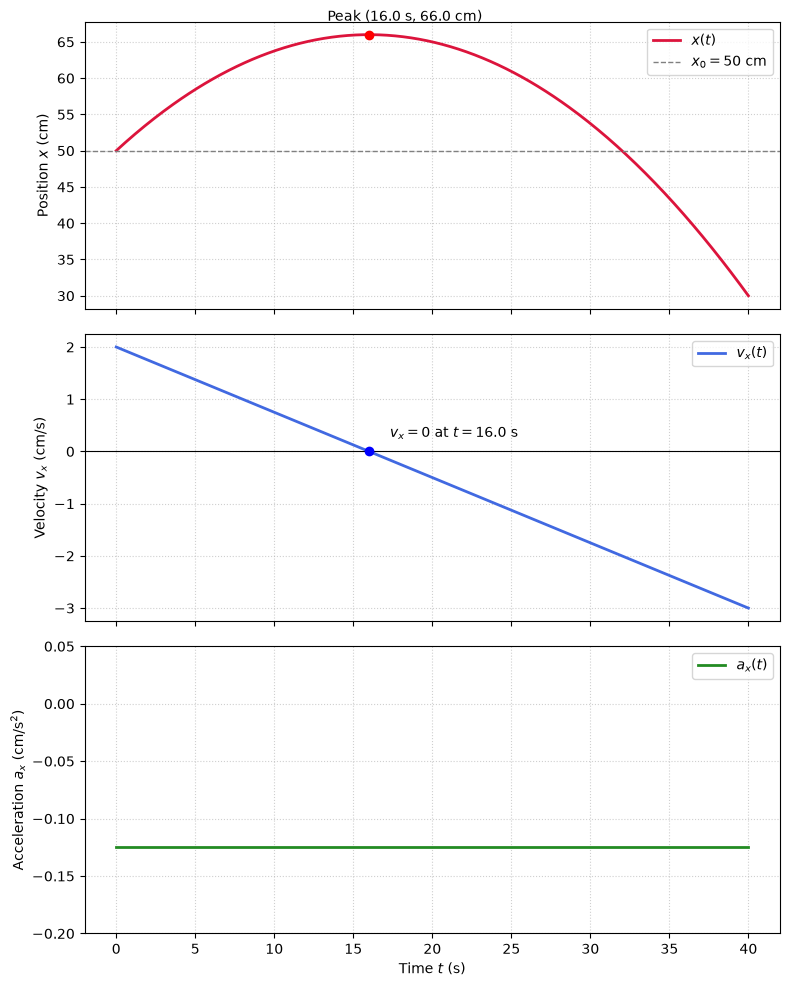

In [ ]:
# Define time array from 0 to 40 seconds
t = np.linspace(0, 40, 400)

# Kinematic equations (in cm, cm/s, cm/s^2)
x = 50.0 + 2.00 * t - 0.0625 * t**2
v_x = 2.00 - 0.125 * t
a_x = np.full_like(t, -0.125)

# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# 1. Position x vs t
ax1.plot(t, x, color="crimson", linewidth=2, label=r"$x(t)$")
ax1.set_ylabel("Position $x$ (cm)")
ax1.axhline(50.0, color="gray", linestyle="--", linewidth=1, label="$x_0 = 50$ cm")
ax1.plot(16.0, 66.0, "ro")  # Peak position
ax1.annotate(
    "Peak (16.0 s, 66.0 cm)",
    (16.0, 66.0),
    textcoords="offset points",
    xytext=(-30, 10),
)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")

# 2. Velocity v_x vs t
ax2.plot(t, v_x, color="royalblue", linewidth=2, label=r"$v_x(t)$")
ax2.set_ylabel("Velocity $v_x$ (cm/s)")
ax2.axhline(0, color="black", linestyle="-", linewidth=0.8)
ax2.plot(16.0, 0.0, "bo")  # Zero velocity point
ax2.annotate(
    "$v_x = 0$ at $t = 16.0$ s",
    (16.0, 0.0),
    textcoords="offset points",
    xytext=(15, 10),
)
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper right")

# 3. Acceleration a_x vs t
ax3.plot(t, a_x, color="forestgreen", linewidth=2, label=r"$a_x(t)$")
ax3.set_xlabel("Time $t$ (s)")
ax3.set_ylabel("Acceleration $a_x$ (cm/s$^2$)")
ax3.set_ylim(-0.2, 0.05)
ax3.grid(True, linestyle=":", alpha=0.6)
ax3.legend(loc="upper right")

plt.tight_layout()
plt.show()

#### P

In [69]:
# Define symbolic time variable and parameter C
t = sp.Symbol("t", real=True, positive=True)
C = sp.Symbol("C", positive=True)
v_target = sp.Symbol("v_target", positive=True)

# Define velocity function v(t)
v = C * t**2

# Compute acceleration a(t)
a = sp.diff(v, t)

# Solve for t when v(t) = v_target
t_sol = sp.solve(sp.Eq(v, v_target), t)[0]

# Express acceleration in terms of v_target
a_at_target = a.subs(t, t_sol)

# Display symbolic results

display(Math(rf"a(t) = {sp.latex(a)}"))
display(Math(rf"v(t) = {sp.latex(t_sol)}"))
display(Math(rf"a_{{target}} = {sp.latex(t_sol)}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [71]:
# Problem constants with units
C = 0.860 * (u.m / u.s**3)
v_target = 12.0 * (u.m / u.s)

# Step 1: Calculate time t when velocity reaches v_target
t_val = np.sqrt(v_target / C)

# Step 2: Calculate acceleration a = 2 * C * t
a_val = 2 * C * t_val

# Print outputs
print(f"Time t when v = {v_target}: {t_val.to(u.s):.3f}")
print(f"Acceleration at that instant: {a_val.to(u.m / u.s**2):.2f}")

Time t when v = 12.0 m / s: 3.735 s
Acceleration at that instant: 6.42 m / s2


#### 2.16

• An astronaut has left the International Space Station to test a
new space scooter. Her partner measures the following velocity changes,
each taking place in a 10 s interval. What are the magnitude, the algebraic
sign, and the direction of the average acceleration in each interval?
Assume that the positive direction is to the right. 

**(a)** At the beginning of
the interval, the astronaut is moving toward the right along the x-axis at
15.0 mus, and at the end of the interval she is moving toward the right at
5.0 m/s. 

**(b)** At the beginning she is moving toward the left at 5.0 m/s,
and at the end she is moving toward the left at 15.0 m/s. 

**(c)** At the beginning
she is moving toward the right at 15.0 m/s, and at the end she is
moving toward the left at 15.0 m/s.

In [ ]:
dt = 10.0 * u.s


def calc_a_avg(vi, vf):
    a = (vf - vi) / dt
    mag = abs(a)
    sign = "+" if a >= 0 else "-"
    direction = "right" if a >= 0 else "left"
    return a, mag, sign, direction


# --- (a) ---
label = "(a)"
vi = 15.0 * (u.m / u.s)
vf = 5.0 * (u.m / u.s)
a, mag, sign, direction = calc_a_avg(vi, vf)
print(
    f"Case {label}: Acceleration = {a}, Magnitude = {mag}, Sign = {sign}, Direction = {direction}"
)

# --- (b) ---
label = "(b)"
vi = -5.0 * (u.m / u.s)
vf = -15.0 * (u.m / u.s)
a, mag, sign, direction = calc_a_avg(vi, vf)
print(
    f"Case {label}: Acceleration = {a}, Magnitude = {mag}, Sign = {sign}, Direction = {direction}"
)

# --- (b) ---
label = "(b)"
vi = 15.0 * (u.m / u.s)
vf = -15.0 * (u.m / u.s)
a, mag, sign, direction = calc_a_avg(vi, vf)
print(
    f"Case {label}: Acceleration = {a}, Magnitude = {mag}, Sign = {sign}, Direction = {direction}"
)


Case (a): Acceleration = -1.0 m / s2, Magnitude = 1.0 m / s2, Sign = -, Direction = left
Case (b): Acceleration = -1.0 m / s2, Magnitude = 1.0 m / s2, Sign = -, Direction = left
Case (b): Acceleration = -3.0 m / s2, Magnitude = 3.0 m / s2, Sign = -, Direction = left
